## Implementing gradient descent to find a local minimum of a function

In [64]:
#Libraries
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import linear_regression
from importlib import reload
reload(linear_regression)
from linear_regression import SimpleLinearRegression

Function: $f(x) = 2x^2 - 3x + 5$

In [2]:
def f(x):
    return 2*x**2 - 3*x + 5

Derivative: $\frac{df}{dx} = 4x - 3$

In [3]:
def df(x):
    return 4*x - 3

Gradient Descent formula:
$x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{df}{dx}$.

Where $\alpha$ is the learning rate, $x_{\text{new}}$ is the current value of $x$ or the value of the previous iteration and $x_{\text{new}}$ is our updated value of $x$ after taking a step along the gradient of the function.

In [4]:
def gradient_descent(x: int, lr: float, iter: int):
    x = 0 # starting point for x (random, usually 0)
    for i in range(iter): #for every iteration
        x = x - lr*df(x) #update x
        if (i + 1) % 10 == 0: # print every 10 iterations
            print(f"Iter {i+1}:  x = {x}, f(x) = {f(x)}")
    return x

In [5]:
minimum = gradient_descent(0.45, 0.1, 100)

Iter 10:  x = 0.7454650368, f(x) = 3.8750411317824502
Iter 20:  x = 0.7499725788116995, f(x) = 3.8750000015038433
Iter 30:  x = 0.7499998341945602, f(x) = 3.875000000000055
Iter 40:  x = 0.7499999989974379, f(x) = 3.875
Iter 50:  x = 0.749999999993938, f(x) = 3.875
Iter 60:  x = 0.7499999999999634, f(x) = 3.875
Iter 70:  x = 0.7499999999999998, f(x) = 3.875
Iter 80:  x = 0.7499999999999999, f(x) = 3.875
Iter 90:  x = 0.7499999999999999, f(x) = 3.875
Iter 100:  x = 0.7499999999999999, f(x) = 3.875


Visualizing gradient descent

In [6]:
x_values = np.linspace(-10, 10, 100)
y_values = f(x_values)

In [7]:
x_values, y_values

(array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
         -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
         -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
         -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
         -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
         -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
         -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
         -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
         -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
         -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
         -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
         -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
         -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
          0.50505051,   0.70707071,   0.90909091,   1.11111111,
          1.31313131,   1.51515152,   1.71717172,   1.91919192,
          2.12121212,   2.32323232,   2.

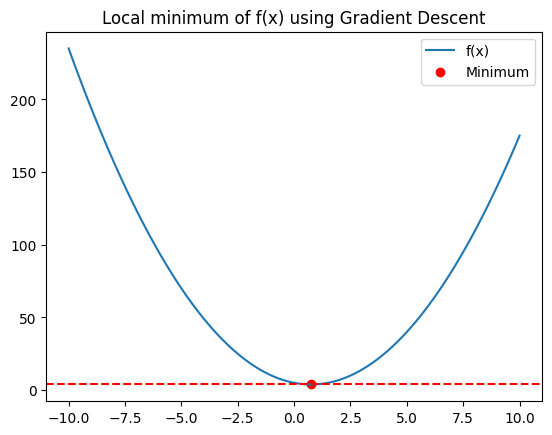

In [8]:
plt.plot(x_values, y_values, label = "f(x)")
plt.scatter(minimum, f(minimum), label = "Minimum", color = "red")
plt.axhline(f(minimum), color="red", linestyle = "--")
plt.title("Local minimum of f(x) using Gradient Descent")
plt.legend()
plt.show()

Learning Curve Visualized

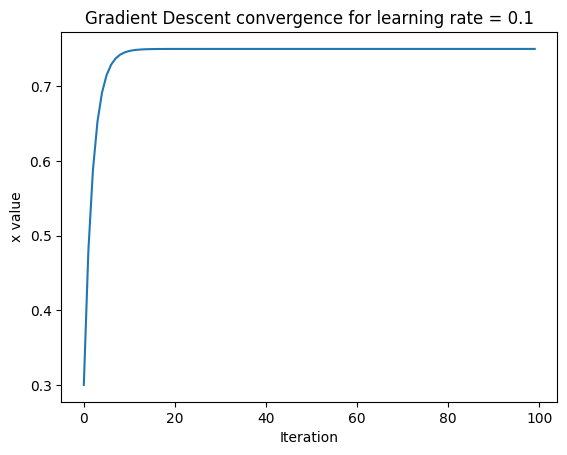

In [9]:
x = 0
lr = 0.1
iter = 100
value_of_x_per_iter = []

for iter in range(iter):
    x = x - lr * df(x)
    value_of_x_per_iter.append(x)

plt.plot(range(iter+1), value_of_x_per_iter)
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Gradient Descent convergence for learning rate = 0.1")
plt.show()


In [10]:
print(np.random.rand(2))

[0.1269219  0.86908875]


## Gradient Descent in Simple Linear Regression

Algorithm steps:
- Start with random initial values for the slope ($m$) and intercept ($b$) of the equation $ y = m x + b $.

- Measure the error using the Mean Squared Error:

     $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (m x + b))^2 $

- Compute the derivate of the loss function (MSE in our case) with respect to $m$ and $b$:  
    1) $\frac{\partial L}{\partial m}$ 
    
    2) $\frac{\partial L}{\partial b}$

- Update $m$ and $b$ parameters to reduce error in next iteration:  
    1)  $m = m - α\frac{\partial L}{\partial m}$

    2)  $b = b - α\frac{\partial L}{\partial b}$

- Repeat until we reach a local minimum 



### Simple Linear Regression Example

In [11]:
#Example
data = pd.read_csv("D:/Studying/Machine Learning/ML Projects/Linear-Regression/data/test.csv")
data.head(10)

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864
5,15,9.805235
6,62,58.874659
7,95,97.617937
8,20,18.395127
9,5,8.746748


In [12]:
print(data.shape)

(300, 2)


In [16]:
x = data["x"]
y = data["y"]
print(x)
print(y)

0      77
1      21
2      22
3      20
4      36
       ..
295    71
296    46
297    55
298    62
299    47
Name: x, Length: 300, dtype: int64
0      79.775152
1      23.177279
2      25.609262
3      17.857388
4      41.849864
         ...    
295    68.545888
296    47.334876
297    54.090637
298    63.297171
299    52.459467
Name: y, Length: 300, dtype: float64


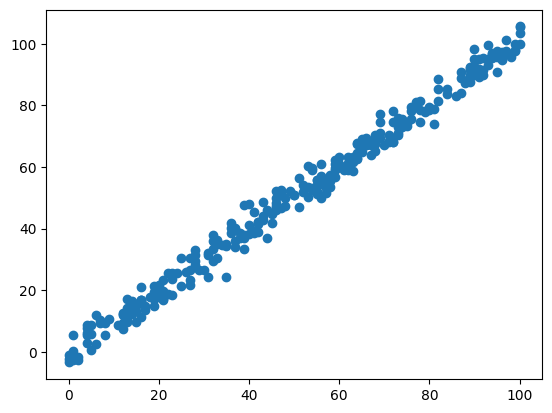

In [17]:
plt.scatter(x,y)
plt.show()

In [26]:
m = np.random.randn()
b = np.random.randn()
print(m,b)

0.4750798769379229 -0.7264923006642483


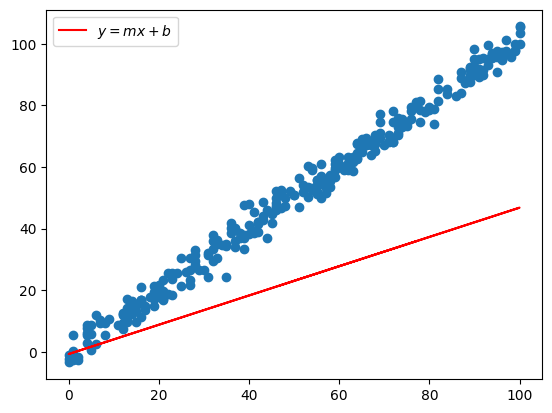

In [27]:
plt.scatter(x, y)
plt.plot(x, m*x + b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()

#### Mean squared error function

In [28]:
def loss_function(Y, Y_pred):
    n = len(Y)
    return (1/n) * sum((Y - Y_pred) ** 2)

In [49]:
m = np.random.randn()
b = np.random.randn()
iter = 100000
lr = 0.0001
n = len(x)

# Loop over all iterations
for i in range(iter):
    y_pred = m * x + b # predictions
    # Gradients
    dM = (-2/n) * np.sum(x * (y - y_pred))
    dB = (-2/n) * np.sum(x - y_pred)
    # Compute new m & b parameters
    m = m - lr*dM
    b = b - lr*dB
    # Print loss, m and b every 1000 iterations
    if (i + 1) % 10000 == 0:
        loss = loss_function(y, y_pred)
        print(f"Iter {i+1}: Loss = {loss}, m = {m}, b = {b}")
    

Iter 10000: Loss = 9.279158805367137, m = 1.0247328477861197, b = -1.1567529555610734
Iter 20000: Loss = 9.339789231583715, m = 1.027187238800756, b = -1.3207796541210008
Iter 30000: Loss = 9.383920019268285, m = 1.0287126057679685, b = -1.422719771336325
Iter 40000: Loss = 9.413837866834417, m = 1.0296605983130802, b = -1.4860740154265275
Iter 50000: Loss = 9.433393578534673, m = 1.03024976137017, b = -1.525447721813015
Iter 60000: Loss = 9.445918809778258, m = 1.0306159173168907, b = -1.5499178859965275
Iter 70000: Loss = 9.453846599945127, m = 1.0308434777107505, b = -1.5651257236659173
Iter 80000: Loss = 9.458829046351502, m = 1.0309849030605702, b = -1.5745771652191547
Iter 90000: Loss = 9.461946976655817, m = 1.031072796780705, b = -1.5804510934774791
Iter 100000: Loss = 9.4638929947075, m = 1.0311274214010362, b = -1.584101651224637


In [32]:
print(loss, m, b)

9.476074326417907 1.0314653934927982 -1.6066882912858687


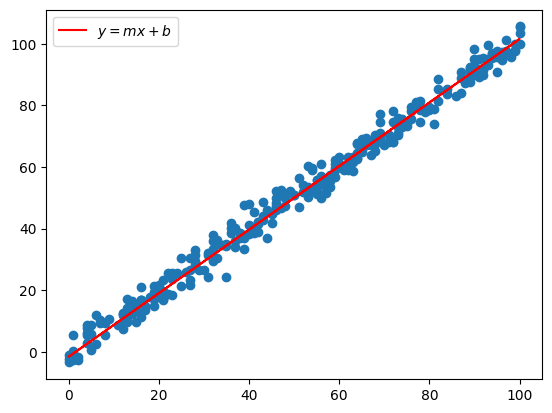

In [35]:
plt.scatter(x, y)
plt.plot(x, m*x + b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()

In [65]:
model = SimpleLinearRegression(0.0001, 100000)

In [66]:
model.gradient_descent(x,y)

Iter 0: Loss = 786587.1773931374, m = 0.6859218356105947, b = 0.010241010219655334
Iter 1000: Loss = 3.5084214564316225, m = 1.0075313846655738, b = -0.0071021294376294964
Iter 2000: Loss = 3.190052829479625, m = 1.0078474352479911, b = -0.028223757288574063
Iter 3000: Loss = 2.9005742842588003, m = 1.0081488049949576, b = -0.04836426641934217
Iter 4000: Loss = 2.6373642156507446, m = 1.0084361758445601, b = -0.06756923068200019
Iter 5000: Loss = 2.3980389137914666, m = 1.0087101980582447, b = -0.08588210698196004
Iter 6000: Loss = 2.1804309764775085, m = 1.0089714916922248, b = -0.10334433361206691
Iter 7000: Loss = 1.982569680517004, m = 1.009220648000542, b = -0.11999542401897802
Iter 8000: Loss = 1.8026631342645754, m = 1.0094582307729523, b = -0.1358730562140097
Iter 9000: Loss = 1.6390820497110847, m = 1.009684777610668, b = -0.15101315803076926
Iter 10000: Loss = 1.4903449871577528, m = 1.0099008011428392, b = -0.16544998842249362
Iter 11000: Loss = 1.3551049388515215, m = 1.010

In [67]:
model.predict(x)

0      77.641388
1      20.842043
2      21.856317
3      19.827769
4      36.056153
         ...    
295    71.555744
296    46.198893
297    55.327359
298    62.427278
299    47.213167
Name: x, Length: 300, dtype: float64